统计现有的benchmark运行结果, 行为方法，列为数据

In [ ]:
import os
import re
import pandas as pd
from pathlib import Path

# 配置
BASE_DIR = Path(".cafe")  # 相对于 notebook_dev/hzy 目录
dataset_name_list = ["bonemarrow", "pancreas", "erythroid_lineage", "pancreas_cellrank"]
method_name_list = [
    "scvelo", "dynamo", "velovi", "celldancer", "pyrovelocity", "veloae", "unitvelo", # velocity
    "palantir", "cytotrace2", "sctc",  # linear, pseudotime
    "cellrank",  # lineage
    "stavia",  # cluster
    "waddingtonot", "moscot"  # time
]

# 扫描 .cafe/{dataset_name}/trajectory_history 文件夹并构造 dataframe


def parse_trajectory_filename(filename: str) -> dict:
    """解析 trajectory 文件名，提取方法名和后端信息

    文件名格式可能为:
    - {timestamp}__{method_name}-{backend}__{random_id}.pkl
    - {simple_name}.pkl (如 ref.pkl, scvelo.pkl)
    """
    name = filename.replace(".pkl", "")

    # 尝试匹配带时间戳的格式: 20251201_094631__scvelo-conda__6WyxCifETS
    timestamp_pattern = r"^\d{8}_\d{6}__(.+)__\w+$"
    match = re.match(timestamp_pattern, name)
    if match:
        method_backend = match.group(1)
        # 分离 method 和 backend: scvelo-conda -> method=scvelo, backend=conda
        if "-" in method_backend:
            parts = method_backend.rsplit("-", 1)
            return {"method": parts[0], "backend": parts[1], "full_name": method_backend}
        return {"method": method_backend, "backend": "unknown", "full_name": method_backend}

    # 简单文件名格式
    return {"method": name, "backend": "local", "full_name": name}


def scan_trajectory_history(base_dir: Path, dataset_list: list, method_list: list = None) -> pd.DataFrame:
    """扫描所有数据集的 trajectory_history 文件夹"""
    records = []

    for dataset_name in dataset_list:
        trajectory_dir = base_dir / dataset_name / "trajectory_history"
        if not trajectory_dir.exists():
            continue

        for pkl_file in trajectory_dir.glob("*.pkl"):
            info = parse_trajectory_filename(pkl_file.name)
            
            # 如果指定了 method_list，则只保留列表中的方法
            if method_list is not None and info["method"] not in method_list:
                continue
                
            records.append({
                "dataset": dataset_name,
                "method": info["method"],
                "backend": info["backend"],
                "full_name": info["full_name"],
                "filename": pkl_file.name,
                "filepath": str(pkl_file),
            })

    return pd.DataFrame(records)


# 执行扫描
df_trajectories = scan_trajectory_history(BASE_DIR, dataset_name_list, method_name_list)
print(f"共扫描到 {len(df_trajectories)} 个 trajectory 结果")
df_trajectories

共扫描到 16 个 trajectory 结果


,dataset,method,backend,full_name,filename,filepath
0,pancreas,scvelo,local,scvelo,scvelo.pkl,.cafe/pancreas/trajectory_history/scvelo.pkl
1,pancreas,celldancer,local,celldancer,celldancer.pkl,.cafe/pancreas/trajectory_history/celldancer.pkl
2,pancreas,stavia,local,stavia,stavia.pkl,.cafe/pancreas/trajectory_history/stavia.pkl
3,pancreas,cytotrace2,local,cytotrace2,cytotrace2.pkl,.cafe/pancreas/trajectory_history/cytotrace2.pkl
4,pancreas,sctc,local,sctc,sctc.pkl,.cafe/pancreas/trajectory_history/sctc.pkl
5,pancreas,veloae,local,veloae,veloae.pkl,.cafe/pancreas/trajectory_history/veloae.pkl
6,pancreas,palantir,local,palantir,palantir.pkl,.cafe/pancreas/trajectory_history/palantir.pkl
7,pancreas,pyrovelocity,local,pyrovelocity,pyrovelocity.pkl,.cafe/pancreas/trajectory_history/pyrovelocity...
8,pancreas,dynamo,local,dynamo,dynamo.pkl,.cafe/pancreas/trajectory_history/dynamo.pkl
9,pancreas,scvelo,conda,scvelo-conda,20251201_094631__scvelo-conda__6WyxCifETS.pkl,.cafe/pancreas/trajectory_history/20251201_094...


In [8]:
# 构造交叉表：行为方法，列为数据集，值为是否存在 (✓/✗)
pivot_table = df_trajectories.pivot_table(
    index="method", 
    columns="dataset", 
    values="filename", 
    aggfunc="count",
    fill_value=0
)

# 确保行顺序与 method_name_list 一致，并补全缺失的方法
pivot_table = pivot_table.reindex(index=method_name_list, fill_value=0)

# 转换为布尔标记
pivot_display = pivot_table.applymap(lambda x: "✓" if x > 0 else "✗")

# 确保列顺序与 dataset_name_list 一致
pivot_display = pivot_display.reindex(columns=[d for d in dataset_name_list if d in pivot_display.columns])

print(f"方法数量: {len(pivot_display)}")
print(f"数据集数量: {len(pivot_display.columns)}")
pivot_display

方法数量: 14
数据集数量: 2


dataset,pancreas,erythroid_lineage
method,,
scvelo,✓,✓
dynamo,✓,✓
velovi,✓,✗
celldancer,✓,✗
pyrovelocity,✓,✗
veloae,✓,✗
unitvelo,✗,✗
palantir,✓,✓
cytotrace2,✓,✓


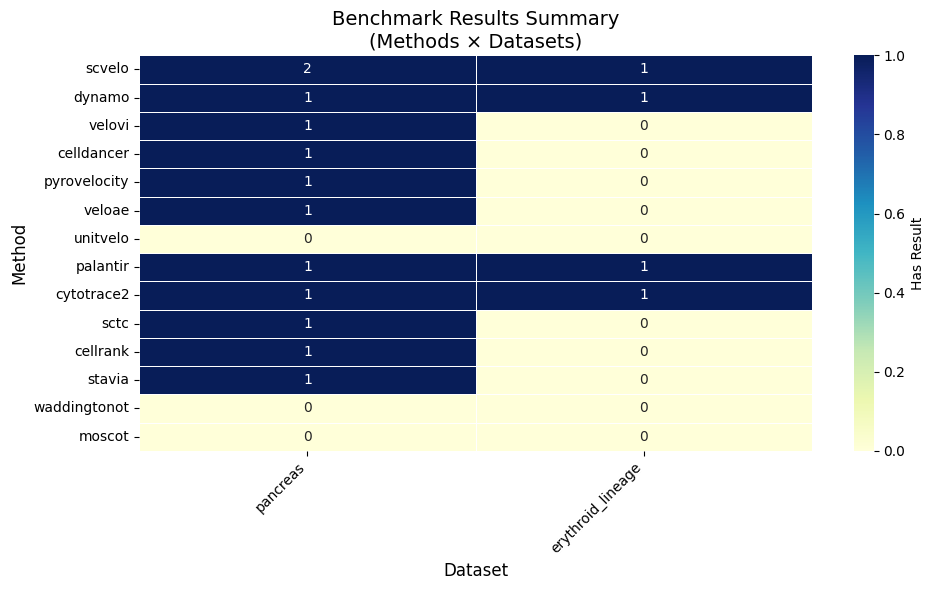

In [9]:
# 可视化热力图
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_table) * 0.4)))

# 创建数值矩阵用于热力图
heatmap_data = pivot_table.reindex(columns=[d for d in dataset_name_list if d in pivot_table.columns])

sns.heatmap(
    heatmap_data > 0, 
    annot=heatmap_data.values,  # 显示实际数量
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={"label": "Has Result"},
    linewidths=0.5,
    ax=ax
)

ax.set_title("Benchmark Results Summary\n(Methods × Datasets)", fontsize=14)
ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Method", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# 按 backend 分组统计
backend_summary = df_trajectories.groupby(["backend", "method"]).size().reset_index(name="count")
backend_pivot = backend_summary.pivot(index="method", columns="backend", values="count").fillna(0).astype(int)
print("各方法的后端分布:")
backend_pivot

各方法的后端分布:


backend,conda,local
method,,
celldancer,0,1
cellrank,0,1
cytotrace2,1,1
dynamo,1,1
palantir,1,1
pyrovelocity,0,1
sctc,0,1
scvelo,2,1
stavia,0,1


In [11]:
# 详细列表：按数据集分组显示所有方法
for dataset in dataset_name_list:
    subset = df_trajectories[df_trajectories["dataset"] == dataset]
    if len(subset) > 0:
        print(f"\n{'='*50}")
        print(f"📊 {dataset.upper()} ({len(subset)} methods)")
        print(f"{'='*50}")
        for _, row in subset.iterrows():
            print(f"  • {row['method']} ({row['backend']})")


📊 PANCREAS (12 methods)
  • scvelo (local)
  • celldancer (local)
  • stavia (local)
  • cytotrace2 (local)
  • sctc (local)
  • veloae (local)
  • palantir (local)
  • pyrovelocity (local)
  • dynamo (local)
  • scvelo (conda)
  • velovi (local)
  • cellrank (local)

📊 ERYTHROID_LINEAGE (4 methods)
  • palantir (conda)
  • dynamo (conda)
  • scvelo (conda)
  • cytotrace2 (conda)


In [12]:
# 导出为 CSV (可选)
output_csv = "benchmark_summary.csv"
pivot_table.to_csv(output_csv)
print(f"已导出汇总表到: {output_csv}")

已导出汇总表到: benchmark_summary.csv
